In [ ]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.ensemble import GradientBoostingRegressor
from econml.dml import CausalForestDML
import joblib

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.expanduser('~/my_ukb_thesis'))

PHASE2_DIR  = os.path.expanduser('~/my_ukb_thesis/phase_II')
OUTPUT_DIR  = os.path.join(PHASE2_DIR, 'outputs')
FIGURES_DIR = os.path.join(PHASE2_DIR, 'figures')

CONFOUNDERS = ['age_defined_baseline', 'genetic_sex', 'BMI', 'uni_degree',
            'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib', 'mental_doctor', 'alc_curr',]
TREATMENTS = ['smk_curr', 'PA_active', 'sleep_adequate']
OUTCOME = 'def_CVD_AF_HF_AFTER'

# read split_B_phase2.parquet and check its shape
df_B = pd.read_parquet(os.path.join(OUTPUT_DIR, 'split_B_phase2.parquet'))
print(f"df_B shape: {df_B.shape}")
assert df_B.shape[0] == 298245, "Unexpected number of rows in df_B"

# load the imputer and scaler
w_imputer = joblib.load(os.path.join(OUTPUT_DIR, 'confounder_imputer.pkl'))
t_imputer = joblib.load(os.path.join(OUTPUT_DIR, 'treatment_imputer.pkl'))
scaler    = joblib.load(os.path.join(OUTPUT_DIR, 'confounder_scaler.pkl'))

In [2]:
# impute W (using transform)
W_df = pd.DataFrame(w_imputer.transform(df_B[CONFOUNDERS]),
                    columns=CONFOUNDERS, index=df_B.index)
W_df['alc_curr'] = np.clip(np.round(W_df['alc_curr']), 0, 1) # round and clip to 0/1

# impute T (using transform)
T_df = pd.DataFrame(t_imputer.transform(df_B[TREATMENTS]),
                    columns=TREATMENTS, index=df_B.index)
for col in TREATMENTS:
    T_df[col] = np.clip(np.round(T_df[col]), 0, 1)

# standardize W (using transform)
W_df[['age_defined_baseline', 'BMI']] = scaler.transform(W_df[['age_defined_baseline', 'BMI']])

# convert W and Y to numpy arrays
W = W_df.values
Y = df_B[OUTCOME].values

In [3]:
print(f"W shape: {W.shape}  (expectation (298245, 9))")
print(f"T shape: {T_df.shape}  (expectation (298245, 3))")
print(f"Y shape: {Y.shape}  (expectation (298245,))")

print(f"\nNaN check:")
print(f"  W: {np.isnan(W).sum()}")
print(f"  T: {T_df.isna().sum().sum()}")
print(f"  Y: {np.isnan(Y).sum()}")

print(f"\nUnique values in treatments:")
for col in TREATMENTS:
    print(f"  {col:25s}: {sorted(T_df[col].unique())}")

print(f"\nafter standardization, age/BMI summary:")
print(W_df[['age_defined_baseline', 'BMI']].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print(f"\nY positive rate: {Y.mean():.4f}")

W shape: (298245, 9)  (expectation (298245, 9))
T shape: (298245, 3)  (expectation (298245, 3))
Y shape: (298245,)  (expectation (298245,))

NaN check:
  W: 0
  T: 0
  Y: 0

Unique values in treatments:
  smk_curr                 : [np.float64(0.0), np.float64(1.0)]
  PA_active                : [np.float64(0.0), np.float64(1.0)]
  sleep_adequate           : [np.float64(0.0), np.float64(1.0)]

after standardization, age/BMI summary:
      age_defined_baseline    BMI
mean                -0.000  0.000
std                  1.000  1.000
min                 -2.370 -3.131
max                  1.948  8.987

Y positive rate: 0.0879


In [4]:
# treatment -> output model filename
MODEL_FILE = {'smk_curr': 'model_smk.pkl',
            'PA_active': 'model_pa.pkl',
            'sleep_adequate': 'model_sleep.pkl',}
# NB1 sanity-check means (5000 rows) for direction reference
SANITY_REF = {'smk_curr': +0.0423,
            'PA_active': -0.0105,
            'sleep_adequate': -0.0217,}
# .npy key per treatment (used when merging later)
ITE_KEY = {'smk_curr': 'ite_smk',
        'PA_active': 'ite_pa',
        'sleep_adequate': 'ite_sleep',}
# SE .npy key per treatment 
SE_KEY  = {'smk_curr': 'se_smk',
        'PA_active': 'se_pa',
        'sleep_adequate': 'se_sleep',}

print(f"Full-sample run, n = {len(Y):,}\n")

ite_store = {}  # hold ITE arrays in memory for merging

for TARGET in TREATMENTS:
    print(f"{'='*50}")
    print(f"=== CausalForestDML: {TARGET} ===")

    T_single = T_df[TARGET].values

    model = CausalForestDML(
        model_y=GradientBoostingRegressor(
            n_estimators=100, max_depth=4, random_state=42),
        model_t=GradientBoostingRegressor(
            n_estimators=100, max_depth=4, random_state=42),
        n_estimators=500,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1,
        verbose=0,)

    # fit + compute full-sample ITE
    t0 = time.time()
    model.fit(Y, T_single, X=W)
    ite = model.effect(W)
    # also get SE for potential future use 
    inf = model.effect_inference(W)
    ite_se = inf.stderr.ravel()   # shape (n,)
    elapsed = (time.time() - t0) / 60
    np.save(os.path.join(OUTPUT_DIR, f'ite_{TARGET}_se.npy'), ite_se)
    ite_store[ITE_KEY[TARGET]] = ite
    ite_store[SE_KEY[TARGET]]  = ite_se
    print(f"  SE mean : {ite_se.mean():.4f},  range: [{ite_se.min():.4f}, {ite_se.max():.4f}]")
    
    

    # save model + ITE (per-treatment, so a crash won't lose everything)
    joblib.dump(model, os.path.join(OUTPUT_DIR, MODEL_FILE[TARGET]))
    np.save(os.path.join(OUTPUT_DIR, f'ite_{TARGET}.npy'), ite)
    ite_store[ITE_KEY[TARGET]] = ite

    # report + direction check vs NB1 sanity check
    print(f"  time   : {elapsed:.1f} min")
    print(f"  mean   : {ite.mean():+.4f}  (NB1 ref = {SANITY_REF[TARGET]:+.4f})")
    print(f"  std    : {ite.std():.4f}")
    print(f"  range  : [{ite.min():.4f}, {ite.max():.4f}]")
    print(f"  %>0    : {(ite > 0).mean()*100:.1f}%")
    print(f"  saved  : {MODEL_FILE[TARGET]}, ite_{TARGET}.npy")


# Merge the 3 ITEs + raw confounders -> ite_results.parquet
print(f"\n{'='*50}")
print("=== Merging ite_results.parquet ===")

ite_df = pd.DataFrame({
    'eid': df_B['eid'].values,
    'ite_smk': ite_store['ite_smk'],
    'ite_pa': ite_store['ite_pa'],
    'ite_sleep': ite_store['ite_sleep'],
    'se_smk'   : ite_store['se_smk'], 
    'se_pa'    : ite_store['se_pa'],   
    'se_sleep' : ite_store['se_sleep']})
for col in ['age_defined_baseline', 'genetic_sex', 'BMI']:
    ite_df[col] = df_B[col].values  # raw values

ite_df.to_parquet(os.path.join(OUTPUT_DIR, 'ite_results.parquet'), index=False)

print(f"ite_results.parquet saved, shape = {ite_df.shape}  (expected (298245, 7))")
print(ite_df[['ite_smk', 'ite_pa', 'ite_sleep']].describe().round(4))

Full-sample run, n = 298,245

=== CausalForestDML: smk_curr ===
  SE mean : 0.0271,  range: [0.0028, 0.1056]
  time   : 7.4 min
  mean   : +0.0431  (NB1 ref = +0.0423)
  std    : 0.0291
  range  : [-0.0889, 0.1829]
  %>0    : 95.9%
  saved  : model_smk.pkl, ite_smk_curr.npy
=== CausalForestDML: PA_active ===
  SE mean : 0.0179,  range: [0.0022, 0.0626]
  time   : 8.0 min
  mean   : -0.0077  (NB1 ref = -0.0105)
  std    : 0.0164
  range  : [-0.1108, 0.0741]
  %>0    : 31.9%
  saved  : model_pa.pkl, ite_PA_active.npy
=== CausalForestDML: sleep_adequate ===
  SE mean : 0.0160,  range: [0.0022, 0.0562]
  time   : 7.9 min
  mean   : -0.0086  (NB1 ref = -0.0217)
  std    : 0.0146
  range  : [-0.1026, 0.0496]
  %>0    : 26.8%
  saved  : model_sleep.pkl, ite_sleep_adequate.npy

=== Merging ite_results.parquet ===
ite_results.parquet saved, shape = (298245, 10)  (expected (298245, 7))
           ite_smk       ite_pa    ite_sleep
count  298245.0000  298245.0000  298245.0000
mean        0.0431   

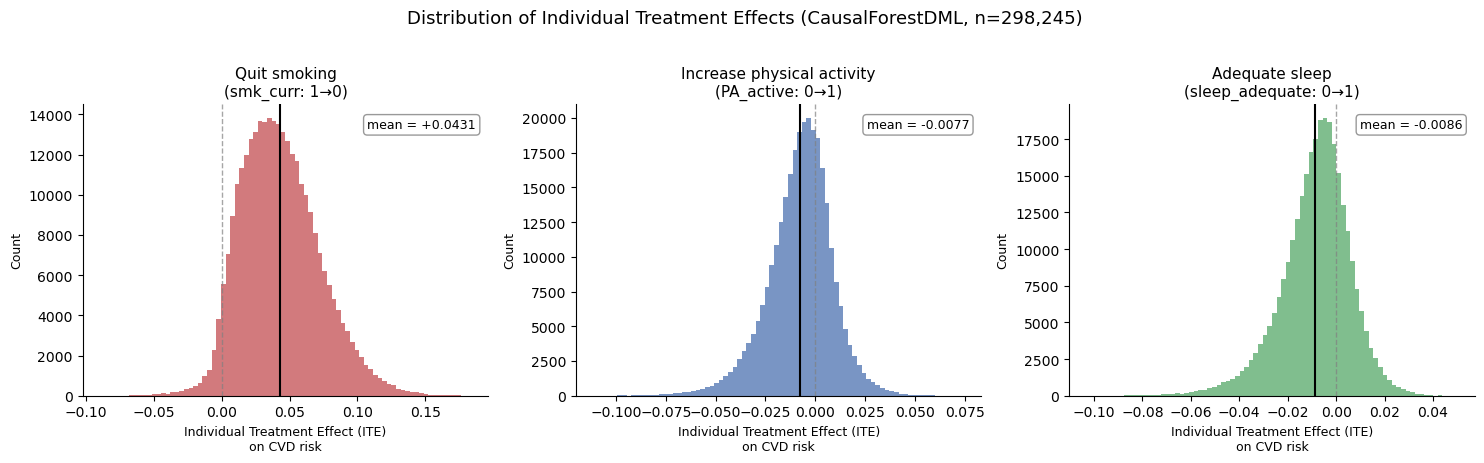

Saved: ite_distributions.png


In [5]:
# load ITEs (from memory if available, else from saved .npy)
try:
    ite_smk = ite_store['ite_smk']
    ite_pa = ite_store['ite_pa']
    ite_sleep = ite_store['ite_sleep']
except NameError:
    ite_smk = np.load(os.path.join(OUTPUT_DIR, 'ite_smk_curr.npy'))
    ite_pa = np.load(os.path.join(OUTPUT_DIR, 'ite_PA_active.npy'))
    ite_sleep = np.load(os.path.join(OUTPUT_DIR, 'ite_sleep_adequate.npy'))

specs = [('Quit smoking\n(smk_curr: 1\u21920)', ite_smk, '#C44E52'),
        ('Increase physical activity\n(PA_active: 0\u21921)', ite_pa, '#4C72B0'),
        ('Adequate sleep\n(sleep_adequate: 0\u21921)', ite_sleep, '#55A868'),]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (title, ite, color) in zip(axes, specs):
    ax.hist(ite, bins=80, color=color, alpha=0.75, edgecolor='none')
    m = ite.mean()
    ax.axvline(0, color='grey', lw=1, ls='--', alpha=0.7)   # null reference
    ax.axvline(m, color='black', lw=1.5, ls='-')            # mean ITE
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Individual Treatment Effect (ITE)\non CVD risk', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.text(0.97, 0.95, f'mean = {m:+.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='grey', alpha=0.8))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of Individual Treatment Effects '
            '(CausalForestDML, n=298,245)', fontsize=13, y=1.02)
fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'ite_distributions.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: ite_distributions.png")

In [6]:
# ============================================================
# Diagnostic: why sleep ITE shrank from sanity check to full run
# ============================================================
import numpy as np

# 1) Is the first-5000 subset representative? Compare to full sample
print("=== 1. First-5000 vs full sample (representativeness) ===")
idx5k = slice(0, 5000)
for name, full_arr, col in [
    ('Y (outcome)',  Y,                              None),
    ('sleep_adeq',   T_df['sleep_adequate'].values,  None),
    ('age (raw)',    df_B['age_defined_baseline'].values, None),
    ('BMI (raw)',    df_B['BMI'].values,             None),
]:
    print(f"  {name:14s}: first5k mean={full_arr[idx5k].mean():.4f}, "
          f"full mean={full_arr.mean():.4f}")

# 2) Re-estimate sleep ITE mean on the SAME 5000 rows using the FULL model
#    If full-model-on-5k ≈ +full mean, the gap was purely the small/shallow model
print("\n=== 2. Full model's ITE on first 5000 rows ===")
ite_sleep_full = np.load(os.path.join(OUTPUT_DIR, 'ite_sleep_adequate.npy'))
print(f"  full model, first 5000 rows : mean={ite_sleep_full[:5000].mean():+.4f}")
print(f"  full model, all 298245 rows : mean={ite_sleep_full.mean():+.4f}")
print(f"  NB1 small model, 5000 rows  : mean=-0.0217 (reference)")

# 3) Is sleep effect concentrated in subgroups? quick age/BMI split
print("\n=== 3. sleep ITE by quick subgroup (full sample) ===")
age = df_B['age_defined_baseline'].values
bmi = df_B['BMI'].values
for label, mask in [
    ('age < 55',   age < 55),
    ('age >= 55',  age >= 55),
    ('BMI < 25',   bmi < 25),
    ('BMI 25-30',  (bmi >= 25) & (bmi < 30)),
    ('BMI >= 30',  bmi >= 30),
]:
    print(f"  {label:12s} (n={mask.sum():>6,}): "
        f"mean ITE = {ite_sleep_full[mask].mean():+.4f}")

=== 1. First-5000 vs full sample (representativeness) ===
  Y (outcome)   : first5k mean=0.0882, full mean=0.0879
  sleep_adeq    : first5k mean=0.7544, full mean=0.7572
  age (raw)     : first5k mean=56.3484, full mean=56.2074
  BMI (raw)     : first5k mean=27.1193, full mean=27.1926

=== 2. Full model's ITE on first 5000 rows ===
  full model, first 5000 rows : mean=-0.0086
  full model, all 298245 rows : mean=-0.0086
  NB1 small model, 5000 rows  : mean=-0.0217 (reference)

=== 3. sleep ITE by quick subgroup (full sample) ===
  age < 55     (n=120,432): mean ITE = -0.0053
  age >= 55    (n=177,813): mean ITE = -0.0108
  BMI < 25     (n=103,078): mean ITE = -0.0064
  BMI 25-30    (n=127,639): mean ITE = -0.0083
  BMI >= 30    (n=67,528): mean ITE = -0.0125
